In [ ]:
import torch
import numpy as np
import ioptics as iop
from ioptics.differentiators import PhysicalBernoulliDifferentiator
from ioptics import ModelOutputDomain, SimulationMode
from torch.optim import Adam
from torch import autograd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import utils

In [128]:
BASE_SEED = 20260416
torch.manual_seed(BASE_SEED)
np.random.seed(BASE_SEED)

def compute_accuracy(logits, labels):
    return (logits.argmax(dim=1) == labels).float().mean().item()

def build_model() -> iop.OpticalNN:
    return iop.OpticalNN(
        iop.ClementsMesh(5, phase_noise_std=0.01),
        iop.SquareActivation(),
        iop.ClementsMesh(5, output_ports=slice(0, 3), phase_noise_std=0.01),
        iop.AbsSquared(),
    )

In [119]:
# 1. Data Preparation
iris = load_iris()
X, y = iris.data, iris.target

# Normalize inputs
X_normalized = utils.normalize_inputs(X, 5, P0=130)
X_normalized_tensor = torch.tensor(X_normalized/2, dtype=torch.complex128, requires_grad=True)

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_normalized_tensor, y, stratify=y, test_size=0.2, random_state=BASE_SEED
)

# Convert to tensors
X_train_tensor = torch.tensor(X_train / 2, dtype=torch.complex128, requires_grad=True)
X_test_tensor = torch.tensor(X_test / 2, dtype=torch.complex128, requires_grad=False)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)


/var/folders/w5/45qn9sdj5y7g11kz1x0w9x1c0000gn/T/ipykernel_25437/2792124136.py:15: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_train_tensor = torch.tensor(X_train / 2, dtype=torch.complex128, requires_grad=True)
/var/folders/w5/45qn9sdj5y7g11kz1x0w9x1c0000gn/T/ipykernel_25437/2792124136.py:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_test_tensor = torch.tensor(X_test / 2, dtype=torch.complex128, requires_grad=False)


In [ ]:
model = build_model()
differentiator = PhysicalBernoulliDifferentiator(simulator=iop.simulator, step_size=0.05, eta=0.02)
criterion = torch.nn.CrossEntropyLoss()

In [ ]:
# 3. Simulator Configuration
from ioptics import SimulatorConfig
sim_cfg = SimulatorConfig(
    mzi_insertion_loss=1.2,
    coupling_loss=0.5,
    laser_noise=True,
    detector_noise=True,
    model_output_domain=ModelOutputDomain.POWER.value
)
simulator = iop.simulator(config=sim_cfg)

In [148]:
history = model.fit_simulation(
    loss_function=criterion,
    X_input=X_train.to(torch.complex64),
    y_label=y_train,
    epochs=2000,
    differentiator=differentiator,
    lr=1,
    batch_size=64,
    verbose=False,
    reset_history=False
)


Training curve saved to physical_bernoulli_vowel_train_curve.png


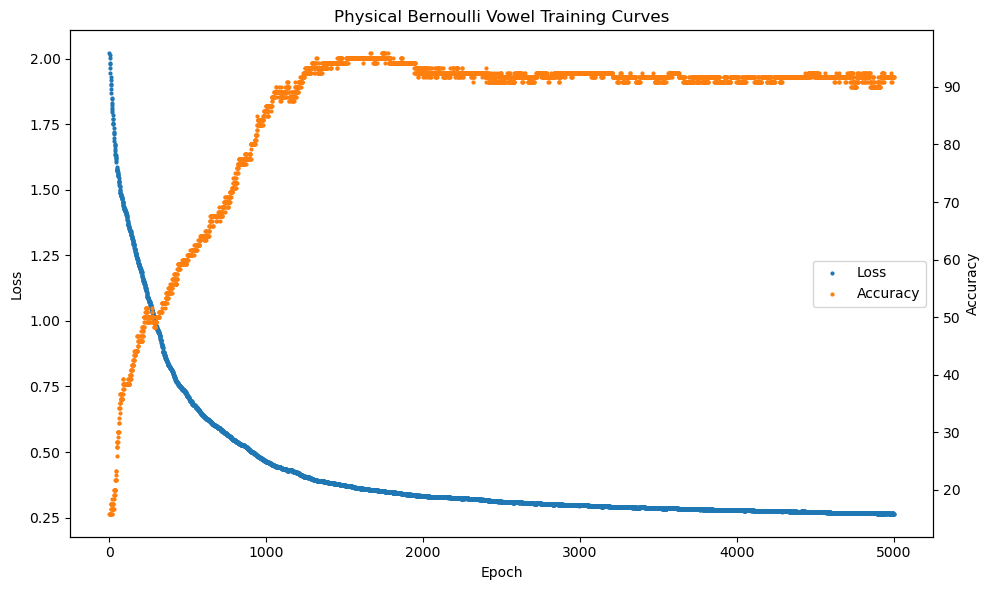

In [152]:
fig, ax1 = plt.subplots(figsize=(10, 6))

color_loss = 'C0'
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
#ax1.plot(range(1, len(history.loss_history) + 1), history.loss_history, color=color_loss, label='Loss')
ax1.scatter(range(1, len(history.loss_history) + 1), history.loss_history, color=color_loss, s=4,label='Loss')

ax2 = ax1.twinx()
color_acc = 'C1'
ax2.set_ylabel('Accuracy')
#ax2.plot(range(1, len(history.accuracy_history) + 1), history.accuracy_history, color=color_acc, label='Accuracy')
ax2.scatter(range(1, len(history.accuracy_history) + 1), history.accuracy_history, color=color_acc, s=4,label='Accuracy')


plt.title('Physical Bernoulli Vowel Training Curves')
fig.tight_layout()

# Create legends for both axes
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='center right')

#plt.savefig('physical_bernoulli_vowel_train_curve.png', dpi=150)
print("\nTraining curve saved to physical_bernoulli_vowel_train_curve.png")
plt.show()
